In [1]:
import geopandas as gpd
from shapely.geometry import LineString

# Raw coordinates as strings from HURDAT2
raw_coords = """
13.7N 45.8W
13.7N 47.4W
13.6N 49.0W
13.6N 50.6W
13.4N 52.0W
13.1N 53.4W
13.0N 55.0W
13.0N 56.6W
13.0N 58.4W
13.1N 59.6W
13.1N 60.3W
13.2N 61.2W
13.2N 62.2W
13.4N 64.0W
13.5N 65.7W
13.7N 67.5W
13.8N 69.2W
14.0N 71.0W
14.2N 72.9W
14.4N 75.0W
14.7N 76.8W
15.1N 78.6W
15.7N 80.5W
16.4N 82.5W
17.3N 84.6W
18.0N 86.4W
18.6N 87.8W
19.4N 88.8W
20.0N 89.7W
20.5N 90.7W
20.9N 91.6W
21.4N 92.3W
21.6N 92.4W
22.0N 92.5W
22.8N 92.6W
23.7N 93.1W
24.4N 93.6W
25.0N 94.4W
25.6N 95.1W
26.3N 95.8W
27.1N 96.3W
27.8N 96.8W
28.0N 96.9W
28.2N 97.1W
28.7N 97.3W
29.0N 97.5W
29.2N 97.4W
29.3N 97.6W
29.1N 97.5W
29.0N 97.2W
28.8N 96.8W
28.6N 96.5W
28.5N 96.2W
28.4N 95.9W
28.2N 95.4W
28.1N 95.0W
28.2N 94.6W
28.5N 94.2W
28.9N 93.8W
29.4N 93.6W
29.8N 93.5W
30.1N 93.4W
30.6N 93.1W
31.3N 92.6W
31.9N 92.2W
32.5N 91.7W
33.4N 90.9W
34.1N 89.6W
34.9N 88.2W
36.0N 87.1W
36.5N 86.4W
37.2N 85.6W
37.9N 84.9W
38.2N 84.7W
"""

# Convert '13.7N 45.8W' → (lon, lat) in decimal degrees
def convert_to_decimal(coord):
    lat_str, lon_str = coord.strip().split()
    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
    return lon, lat

# Parse all coordinates
points = [convert_to_decimal(line) for line in raw_coords.strip().split('\n')]

# Create a LineString geometry
line = LineString(points)

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(index=[0], geometry=[line], crs="EPSG:4326")

# Save as shapefile
gdf.to_file("Hurricane_Harvey_Track.shp")


CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Program Files\PostgreSQL\15\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 4 is expected. It comes from another PROJ installation.

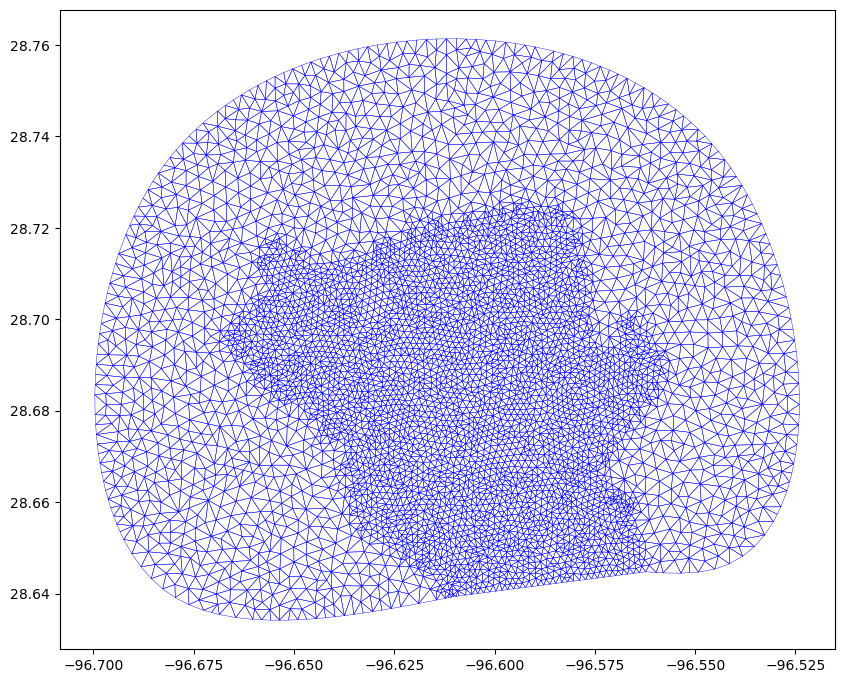

In [6]:
import mikeio
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Polygon

# Load DFSU file
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"
ds = mikeio.open(dfsu_path)
mesh = ds.geometry

# Use element_table for element connectivity
polygons = [Polygon(mesh.node_coordinates[conn]) for conn in mesh.element_table]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:32614")  # UTM 14N

# Convert to WGS 84 (lat/lon) for basemap
gdf = gdf.to_crs(epsg=4326)

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=0.3)
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title("Port Lavaca DFSU Mesh with Basemap", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [4]:
dir(ds)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_deletevalue',
 '_dfs_read_item_time_func',
 '_equidistant',
 '_filename',
 '_geometry',
 '_items',
 '_n_timesteps',
 '_read_geometry',
 '_start_time',
 '_timestep',
 '_type',
 'append',
 'deletevalue',
 'end_time',
 'extract_track',
 'geometry',
 'get_overset_grid',
 'items',
 'n_items',
 'n_timesteps',
 'read',
 'show_progress',
 'start_time',
 'time',
 'timestep']